In [1]:
import pandas as pd

def main():
    print("Loading dataset...")
    # 1. Load the master dataset
    # Ensure 'Final_data.csv' is in the same directory as this script
    df = pd.read_csv('Final_data.csv')

    print("Cleaning and transforming data...")
    # 2. Create Age Buckets (e.g., 18-29, 30-39) to make the data actionable
    bins = [18, 30, 40, 50, 60, 100]
    labels = ['18-29', '30-39', '40-49', '50-59', '60+']
    df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

    print("Running demographic analysis...")
    # 3. Group by Gender AND Age_Group to find the most popular Workout_Type
    popular_workouts = df.groupby(['Gender', 'Age_Group'], observed=False)['Workout_Type'].apply(
        lambda x: x.mode()[0] if not x.mode().empty else 'No Data'
    ).reset_index()

    # 4. Rename columns for clarity
    popular_workouts.columns = ['Gender', 'Age_Group', 'Most_Popular_Workout']

    print("Exporting insights...")
    # 5. Save the final insight to a new CSV for stakeholders
    output_file = 'demographic_workout_insights.csv'
    popular_workouts.to_csv(output_file, index=False)

    print(f"\nAnalysis complete! Results saved to '{output_file}'.")
    print("\n--- Preview of Results ---")
    print(popular_workouts.head(10))

if __name__ == "__main__":
    main()

Loading dataset...
Cleaning and transforming data...
Running demographic analysis...
Exporting insights...

Analysis complete! Results saved to 'demographic_workout_insights.csv'.

--- Preview of Results ---
   Gender Age_Group Most_Popular_Workout
0  Female     18-29             Strength
1  Female     30-39             Strength
2  Female     40-49             Strength
3  Female     50-59                 Yoga
4  Female       60+                  NaN
5    Male     18-29               Cardio
6    Male     30-39             Strength
7    Male     40-49                 Yoga
8    Male     50-59             Strength
9    Male       60+                  NaN


Loading data for visualization...


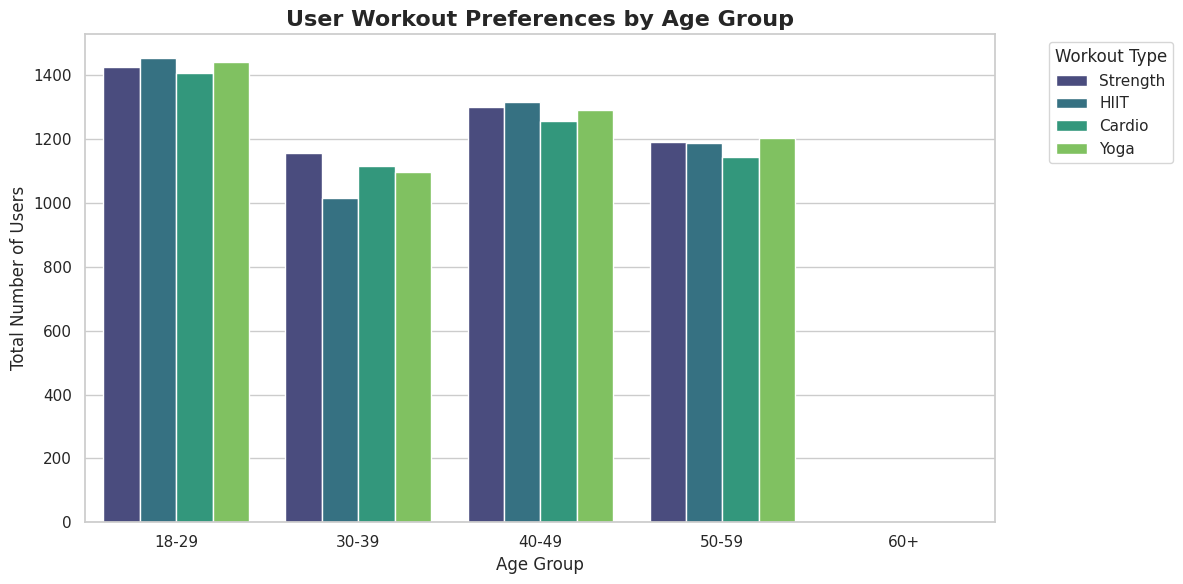

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Loading data for visualization...")
# 1. Load the original raw dataset
df = pd.read_csv('Final_data.csv')

# 2. Recreate our Age Groups
bins = [18, 30, 40, 50, 60, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# 3. Set up the canvas and style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 4. Generate a Grouped Bar Chart automatically counting the users
sns.countplot(
    data=df,
    x="Age_Group",
    hue="Workout_Type",
    palette="viridis"
)

# 5. Add professional labels for the Stakeholders
plt.title("User Workout Preferences by Age Group", fontsize=16, fontweight='bold')
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Total Number of Users", fontsize=12)
plt.legend(title="Workout Type", bbox_to_anchor=(1.05, 1), loc='upper left')

# 6. Display the chart!
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

print("Loading demographic data...")
df = pd.read_csv('Final_data.csv')

# 1. Filter the data to ONLY include our target Option A demographic (18 to 39)
target_demo = df[(df['Age'] >= 18) & (df['Age'] < 40)]

# 2. Calculate the percentage breakdown of their Experience Levels
experience_breakdown = target_demo['Experience_Level'].value_counts(normalize=True) * 100

print("\n--- Experience Level Breakdown (Ages 18-39) ---")
print(experience_breakdown.round(1).astype(str) + '%')

Loading demographic data...

--- Experience Level Breakdown (Ages 18-39) ---
Experience_Level
1.00    24.8%
2.00    11.3%
1.99     9.1%
2.01     8.6%
1.01     8.0%
3.00     5.2%
2.99     4.5%
2.02     4.4%
1.98     4.3%
3.01     4.2%
1.02     4.1%
3.02     2.2%
2.98     2.0%
1.97     1.7%
2.03     1.4%
1.03     1.3%
2.97     0.8%
3.03     0.7%
2.04     0.3%
1.96     0.3%
1.04     0.3%
3.04     0.2%
2.96     0.1%
1.05     0.1%
1.95     0.0%
2.05     0.0%
3.05     0.0%
Name: proportion, dtype: object
